In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time

# exercise 04

### exercise 4.1

By using the dimensionless parameters $a =\beta J$, $b=\beta h$, we get: $\lambda_{\pm} = \exp{(a)}(\cosh{(b)\pm \sqrt{\sinh^{2}{(b)} + \exp{(-4 a)}}})$ and $Z = \lambda_{+} + \lambda_{-}$.

For the Magnetisation $\left\langle M \right\rangle$ this gives us: 

\begin{align} 
\left\langle M \right\rangle = N \frac {(\lambda_+^N- (-\lambda_-)^N)\sqrt{\sinh^2(b)+e^{-4a}}e^{4a} \sinh(b)}{(\lambda_+^N + (-\lambda_-)^N)(e^{4a} \sinh^2(b)+1)} \; ,
\end{align}
with 

\begin{align} 
\lambda_\pm = \left(e^{a} \left( \cosh(b) \pm \sqrt{ \sinh^2(b)+e^{-4a}}\right)\right) \; .
\end{align}

In [5]:
def sqrt(a, b):
    return(np.sqrt(np.sinh(b)**2 + np.exp(-4*a)))

def M_derived(a,b,N):
    lam_p = np.exp(a)*(np.cosh(b) + np.sqrt(np.sinh(b)**2+np.exp(-4*a)))
    lam_m = np.exp(a)*(np.cosh(b) - np.sqrt(np.sinh(b)**2+np.exp(-4*a)))
    diff_Z_1 = N*(lam_p**N-(-lam_m)**N)*np.sqrt(np.sinh(b)**2+np.exp(-4*a))*np.exp(4*a)*np.sinh(b)
    diff_Z_2 = (lam_p**N+(-lam_m)**N)*(np.exp(4*a)*np.sinh(b)**2+1)
    return diff_Z_1/diff_Z_2

def m_derived(a, b, N):
    return(M_derived(a, b, N)/N)

def m_theo(a, b):
    return((np.sinh(b))/(sqrt(a, b)))

In [6]:
J = 0.75
beta = 1
h = np.linspace(-1, 1, 50)
a1 = beta*J
b1 = beta * h
N = [1, 2, 4, 8, 16, 300]

In [7]:
m_values = np.zeros((len(N), len(h)))
for k in range(len(N)):
    for l in range(len(h)):
        m_values[k, l] = m_derived(a1, b1[l], N[k])

m_values_theo = np.zeros(len(h))
for m in range(len(h)):
    m_values_theo[m] = m_theo(a1, b1[m])

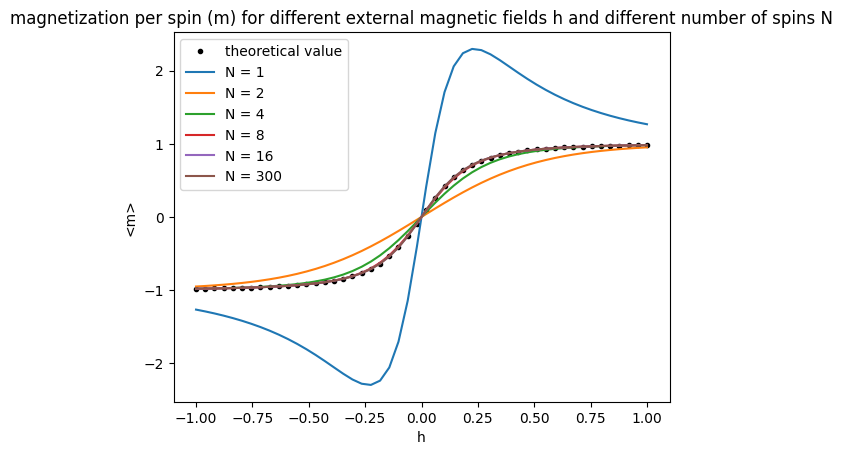

In [8]:
plt.plot(h, m_values_theo, linestyle = 'None', marker = '.', color = 'black', label = 'theoretical value')
for i in range(len(N)):
    plt.plot(h, m_values[i, :], label = f'N = {N[i]}')
plt.title('magnetization per spin (m) for different external magnetic fields h and different number of spins N')
plt.xlabel('h')
plt.ylabel('<m>')
plt.legend()

plt.show()

In [9]:
def H(a, lattice):
    return(-a*(np.roll(lattice,-1)*lattice+np.roll(lattice,1)*lattice).sum())

def action(a, b, lattice):
    S = H(a,lattice)-b*lattice.sum()
    return(S)

In [10]:
def delta_action(a, b, lattice, x):
    if len(lattice)-1 in [x]:
        dS = -2*a*(lattice[0]*lattice[x]+ lattice[x-1]*lattice[x])-2*b*lattice[x]
    else: 
        dS = -2*a*(lattice[x+1]*lattice[x]+ lattice[x-1]*lattice[x])-2*b*lattice[x]
    return(dS)

In [11]:
expo = np.arange(1, 9)
N =(10.0**expo)
time1 = np.zeros(len(N))
time2 = np.zeros(len(N))
for s in range(len(N)):
    sigma = np.random.choice([-1,1], size=int(N[s]))
    start1 = time.process_time()
    p = action(a1,b1,sigma)
    time1[s] = time.process_time() - start1
    start2 = time.process_time()
    p = delta_action(a1,b1,sigma,1)
    time2[s] = time.process_time() - start2

<>:2: SyntaxWarning: invalid escape sequence '\D'
<>:2: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_14856/3055089987.py:2: SyntaxWarning: invalid escape sequence '\D'
  plt.plot(N,time2,marker='.', label='$\Delta S$')


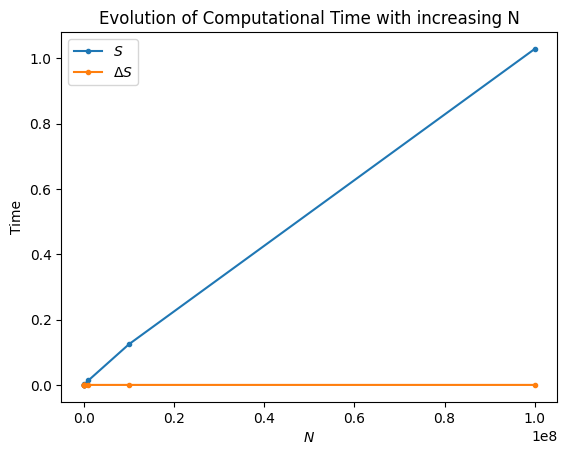

In [25]:
plt.plot(N,time1,marker='.', label='$S$')
plt.plot(N,time2,marker='.', label='$\Delta S$')
plt.title('Evolution of Computational Time with increasing N')
plt.xlabel('$N$')
plt.ylabel('Time')
plt.legend()
plt.show()



In [21]:
def MC(J,h,lattice1,steps):
    # start with distribution "start"
    lat_curr = lattice1
    m = np.zeros(steps)
    length = len(lattice1)
    
    for s in range(steps):
        #for each step choose position
        x = np.random.choice(length, 1)
        if np.random.uniform(low=0, high=1) < np.exp(delta_action(J,h,lat_curr,x)): # accepting condition
            lat_curr[x] = lat_curr[x]*(-1)
        else:
            pass
        #calculate M/N
        m[s] = lat_curr.sum()/(len(lattice1))
    return m


In [22]:
h = np.linspace(-1,1,20)
steps = 10000
J = 0.75 
sigma =  np.ones(20)
m_h = np.zeros(len(h))
m_std = np.zeros(len(h))
for x in range(len(h)):
    m1 = MC(J,h[x],sigma,steps)   
    m_h[x] = m1.mean()
    m_std[x] = m1.std()

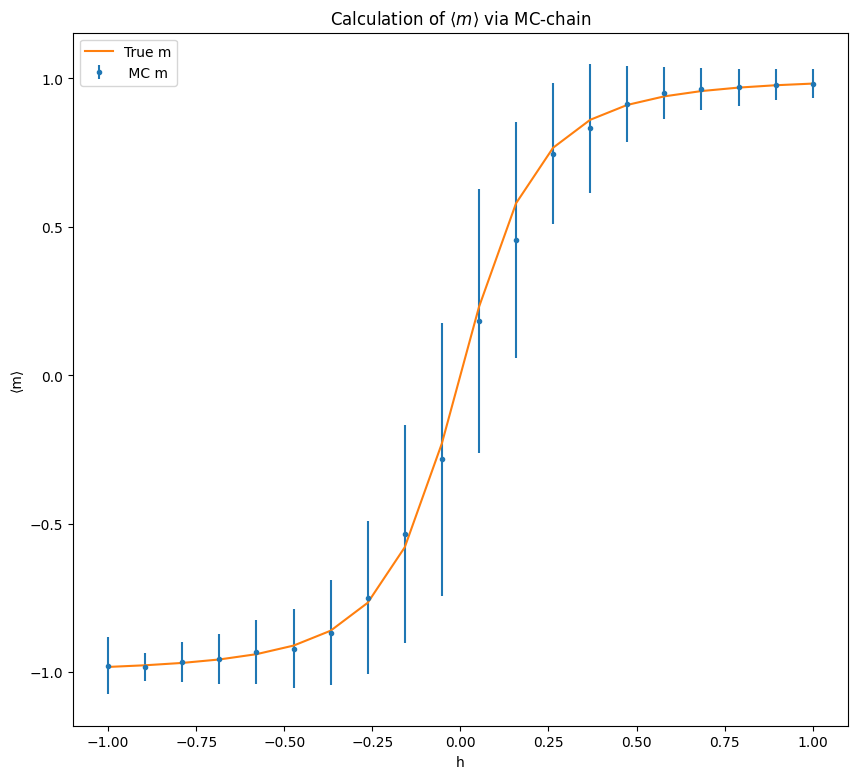

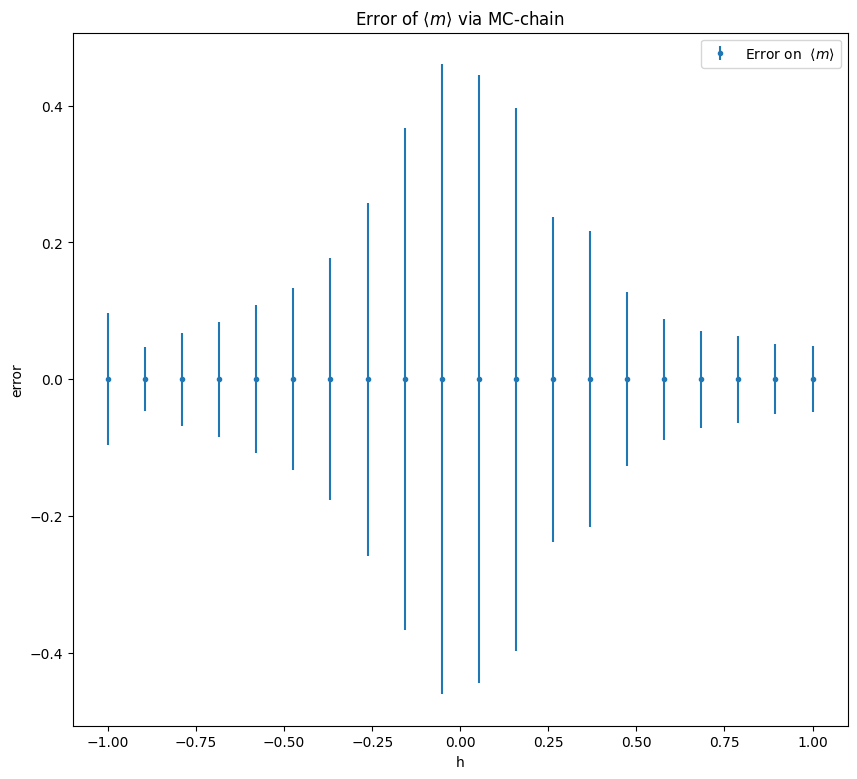

In [24]:
fig,ax =plt.subplots(figsize=(10,9))     
ax.errorbar(h,m_h,yerr = m_std, marker ='.', linestyle =' ', label =' MC m')
ax.set_xlabel('h')
ax.set_ylabel('⟨m⟩')
ax.plot(h,m_theo(J,h), label = 'True m')
ax.legend()
plt.title('Calculation of $⟨m⟩$ via MC-chain')
plt.show()
fig,ax =plt.subplots(figsize=(10,9)) 
ax.errorbar(h,np.zeros(len(h)),yerr = m_std, marker ='.', linestyle =' ', label ='Error on  $⟨m⟩$')
ax.legend()
ax.set_xlabel('h')
ax.set_ylabel('error')
plt.title('Error of $⟨m⟩$ via MC-chain')
plt.show()